<div style="font-family: Arial; font-size: 14pt;">

# Stock Price Prediction with Linear Regression

Here we will be exploring how to predict the next day’s stock closing price using historical data.  
The goal is not to perfectly forecast the market but to build a simple machine learning model to understand price trends.

### What we will do :
- Fetch historical stock prices from Yahoo Finance  
- Prepare the data for modeling, including preprocessing and feature creation  
- Train a Linear Regression model to predict the next day’s closing price  
- Evaluate how well the model performs  
- Make a prediction for the next day  

</div>

In [29]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [31]:
ticker = "AAPL"
df = yf.download(ticker, start="2015-01-01", end="2024-01-01")

df.columns = df.columns.droplevel(1)
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
df.columns.name = None

df.reset_index(inplace=True)

df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.214890,24.682222,23.776350,24.671147,212818400
1,2015-01-05,23.532722,24.064285,23.346676,23.984551,257142000
2,2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
3,2015-01-07,23.864944,23.964612,23.632385,23.743127,160423600
4,2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


<class 'pandas.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    2264 non-null   datetime64[s]
 1   Close   2264 non-null   float64      
 2   High    2264 non-null   float64      
 3   Low     2264 non-null   float64      
 4   Open    2264 non-null   float64      
 5   Volume  2264 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 106.3 KB


,Date,Close,High,Low,Open,Volume
count,2264,2264.000000,2264.000000,2264.000000,2264.000000,2.264000e+03
mean,2019-07-01 19:15:03,81.318618,82.142376,80.412963,81.250262,1.237614e+08
min,2015-01-02 00:00:00,20.584814,20.887866,20.386578,20.507342,2.404830e+07
25%,2017-04-02 06:00:00,32.784023,32.980011,32.603056,32.796159,7.831732e+07
50%,2019-07-02 12:00:00,51.172962,51.983520,50.799039,51.319693,1.056556e+08
75%,2021-09-29 06:00:00,138.887665,140.572295,136.389119,138.829279,1.486811e+08
max,2023-12-29 00:00:00,196.073105,197.567574,194.974504,195.984034,6.488252e+08
std,NaN,55.938537,56.511319,55.304136,55.883934,6.818417e+07


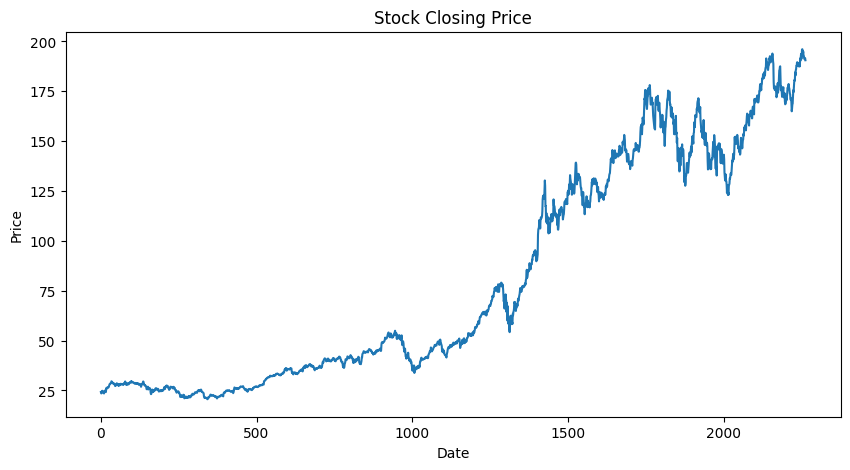

In [32]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [33]:
df = df[['Close']].copy()

# Create lag features
df['Prev_Close'] = df['Close'].shift(1)
df['Prev_Close_2'] = df['Close'].shift(2)

df.dropna(inplace=True)

df.head()

,Close,Prev_Close,Prev_Close_2
2,23.534939,23.532722,24.214890
3,23.864944,23.534939,23.532722
4,24.781891,23.864944,23.534939
5,24.808477,24.781891,23.864944
6,24.197176,24.808477,24.781891


In [34]:
X = df[['Prev_Close', 'Prev_Close_2']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 7.6949


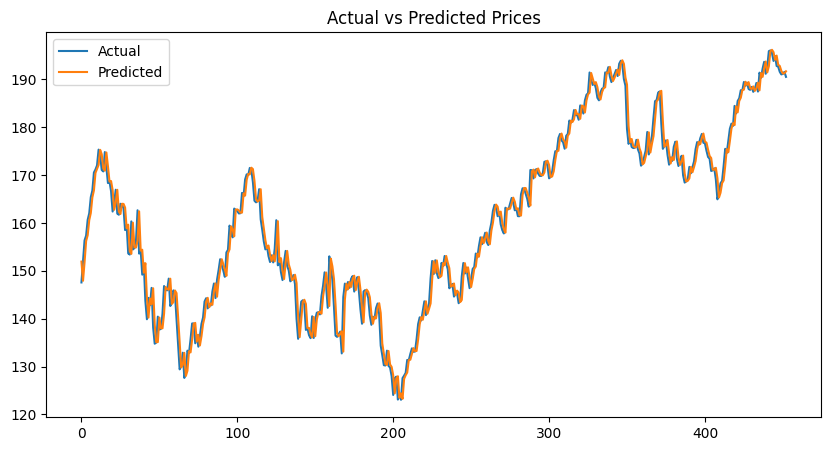

In [36]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

In [37]:
last_close = df.iloc[-1]['Close']
prev_close = df.iloc[-2]['Close']

next_day = model.predict([[last_close, prev_close]])

print(f"Predicted next closing price: {next_day[0]:.2f}")

Predicted next closing price: 190.75


In [38]:
import joblib

joblib.dump(model, "stock_model.pkl")

['stock_model.pkl']

In [39]:
df['MA_10'] = df['Close'].rolling(window=10).mean()
df.dropna(inplace=True)

df.head(15)

,Close,Prev_Close,Prev_Close_2,MA_10
11,24.079786,23.475134,23.658966,24.113232
12,24.263618,24.079786,23.475134,24.186100
13,24.894846,24.263618,24.079786,24.289090
14,25.023310,24.894846,24.263618,24.313232
15,25.049885,25.023310,24.894846,24.337373
16,24.172810,25.049885,25.023310,24.334936
17,25.539366,24.172810,25.049885,24.447671
18,26.334503,25.539366,24.172810,24.649222
19,25.949114,26.334503,25.539366,24.878237
20,26.274693,25.949114,26.334503,25.158193


In [40]:
df['Return'] = df['Close'].pct_change()

df.head(10)

,Close,Prev_Close,Prev_Close_2,MA_10,Return
11,24.079786,23.475134,23.658966,24.113232,NaN
12,24.263618,24.079786,23.475134,24.186100,0.007634
13,24.894846,24.263618,24.079786,24.289090,0.026015
14,25.023310,24.894846,24.263618,24.313232,0.005160
15,25.049885,25.023310,24.894846,24.337373,0.001062
16,24.172810,25.049885,25.023310,24.334936,-0.035013
17,25.539366,24.172810,25.049885,24.447671,0.056533
18,26.334503,25.539366,24.172810,24.649222,0.031134
19,25.949114,26.334503,25.539366,24.878237,-0.014634
20,26.274693,25.949114,26.334503,25.158193,0.012547
